# Exercise: Segmentation Using Deep Learning

## Input Data

Use the image "931_H7_2_bin4.tif" from the example data. It contains three channels:
- Channel 0: Nuclei (DAPI)
- Channel 1: Some unknown marker
- Channel 2: Actin (Phalloidin)

## Objectives:

1. Segment the nuclei and entire cells (cytoplasm) using Cellpose
    - Use different pre-trained models (e.g. nuclei, cyto, cyto2, cyto3)
    - Adapt diameter parameter to your data
    - Use the appropriate channel(s!) for segmentation
1. Obtain masks for just the cytoplasm of each cell (excluding the nucleus)
1. Extract the average intensity of the Actin channel in the cytoplasm of each cell
1. Try cellpose on another image from the example data

In [1]:
from cellpose import models
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, segmentation

## Load the image

In [2]:
# im = io.imread('../_static/data/cells_shaded.tif')
im = io.imread('../_static/data/931_H7_2_bin4.tif')
print('Shape of the image:', im.shape)

Shape of the image: (512, 512, 3)


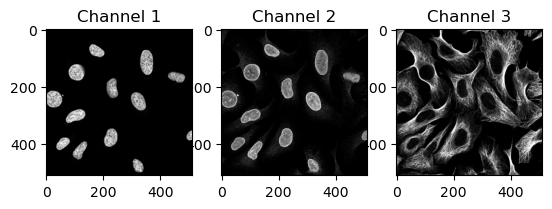

In [3]:
fig, axs = plt.subplots(1, 3)
for i in range(3):
    axs[i].imshow(im[:, :, i], cmap='gray')
    axs[i].set_title(f'Channel {i+1}')

## Segment nuclei using Cellpose

In [4]:
# instantiate a Cellpose model for nuclei

model_nuclei = models.CellposeModel(model_type='nuclei') 

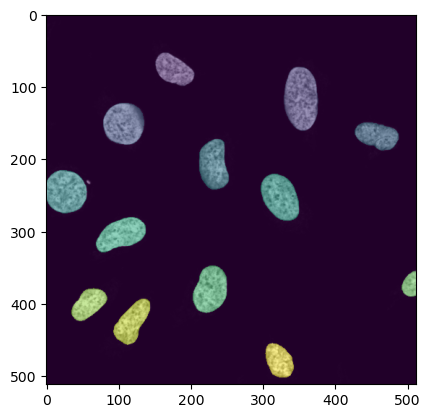

In [5]:
diameter = 50

masks_n, flows, styles = model_nuclei.eval(im[:, :, 0], diameter=diameter)

b_n = segmentation.find_boundaries(masks_n)

plt.figure()
plt.imshow(im[:, :, 0], cmap='gray')
plt.imshow(masks_n, alpha=0.5)
# plt.imshow(b_n, cmap='hot', alpha=0.5 * b_n)

## Segment cells using Cellpose

In [6]:
# instantiate a Cellpose model for cytoplasm

model_cyto = models.CellposeModel(model_type='cyto3') 

In [7]:
# get help for the eval function

model_cyto.eval?

Signature:
model_cyto.eval(
    x,
    batch_size=8,
    resample=True,
    channels=None,
    channel_axis=None,
    z_axis=None,
    normalize=True,
    invert=False,
    rescale=None,
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    do_3D=False,
    anisotropy=None,
    flow3D_smooth=0,
    stitch_threshold=0.0,
    min_size=15,
    max_size_fraction=0.4,
    niter=None,
    augment=False,
    tile_overlap=0.1,
    bsize=224,
    interp=True,
    compute_masks=True,
    progress=None,
)
Docstring:
segment list of images x, or 4D array - Z x nchan x Y x X

Args:
    x (list, np.ndarry): can be list of 2D/3D/4D images, or array of 2D/3D/4D images
    batch_size (int, optional): number of 224x224 patches to run simultaneously on the GPU
        (can make smaller or bigger depending on GPU memory usage). Defaults to 8.
    resample (bool, optional): run dynamics at original image size (will be slower but create more accurate boundaries). Defaults to True.
    c

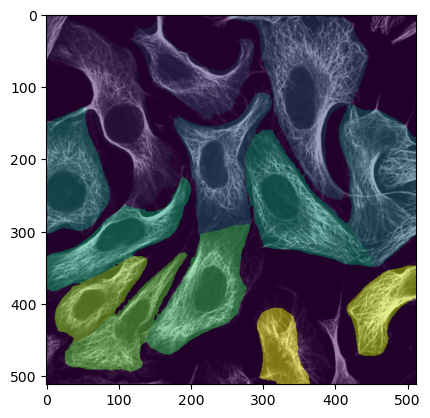

In [ ]:
diameter = 200 # found this by inspecting the image first and trying a few values

masks_c, flows, styles = model_cyto.eval(im[:, :, [0, 2]], diameter=diameter, channels=[2, 1])

plt.figure()
plt.imshow(im[:, :, 2], cmap='gray')
plt.imshow(masks_c, alpha=0.5)

## Show nuclei and cells together

## Determine cytoplasm

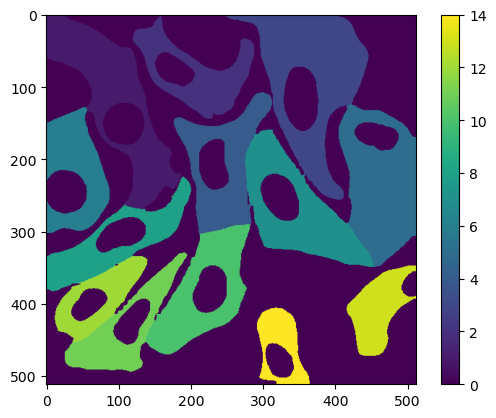

In [ ]:
# create binary mask for cytoplasm only (i.e. where there is cytoplasm but no nucleus)
binary_only_cytoplasm = ((masks_c > 0) > (masks_n > 0))

# multiply with the cytoplasm labels to get the labels back for cytoplasm only
masks_only_cytoplasm = masks_c * binary_only_cytoplasm

plt.figure()
plt.imshow(masks_only_cytoplasm)
plt.colorbar()

## Extract average intensity in cytoplasm

In [23]:
from skimage.measure import regionprops_table

props = regionprops_table(
    masks_only_cytoplasm,
    intensity_image=im[:, :, 2],
    properties=['label', 'mean_intensity'])

import pandas as pd
df = pd.DataFrame(props)
df.head()

,label,mean_intensity
0,1,17166.387912
1,2,17576.872032
2,3,21547.709470
3,4,16505.745377
4,5,18779.828511


In [25]:
print('The mean intensity of Actin in the cytoplasm is:', df['mean_intensity'].mean())

The mean intensity of Actin in the cytoplasm is: 18784.245935808936


## Segment rice

In [26]:
img = io.imread('../_static/data/rice.png')

In [27]:
# instantiate a Cellpose model for cytoplasm

model_cyto = models.CellposeModel(model_type='cyto3')
masks, flows, styles = model_cyto.eval(img, diameter=20, channels=[0, 0])

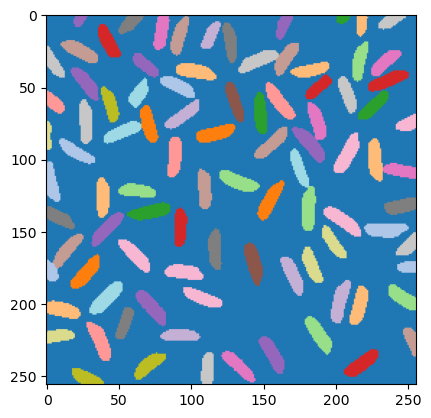

In [30]:
plt.figure()
plt.imshow(
    np.array([0] + list(np.random.randint(0, 50, (np.max(masks)))))[masks],
    cmap='tab20'
)

## Try another image

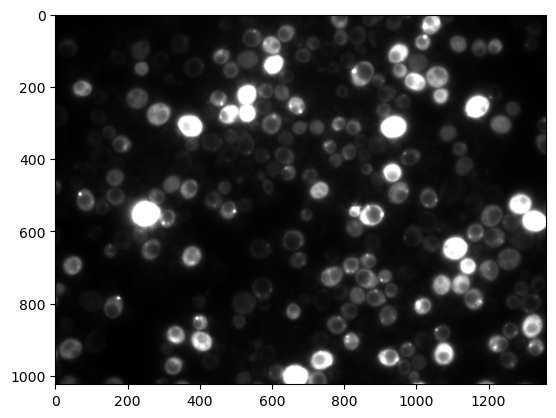

In [16]:
img = io.imread("/Users/albertm/teaching/lab_course/scu_lab_course_ia/_static/data/fiji/segmentation/13901.tif")
plt.figure()
plt.imshow(img, cmap='gray')

In [17]:
# instantiate a Cellpose model for cytoplasm

model_cyto = models.CellposeModel(model_type='cyto3') # other options: 'nuclei', 'cyto2'
masks, flows, styles = model_cyto.eval(
    img,
    diameter=50,
    channels=[0, 0], # when using two channels: [cytoplasm, nucleus], this would be [1, 2]
    cellprob_threshold=0, # this is only set so that cellpose returns more output
    )

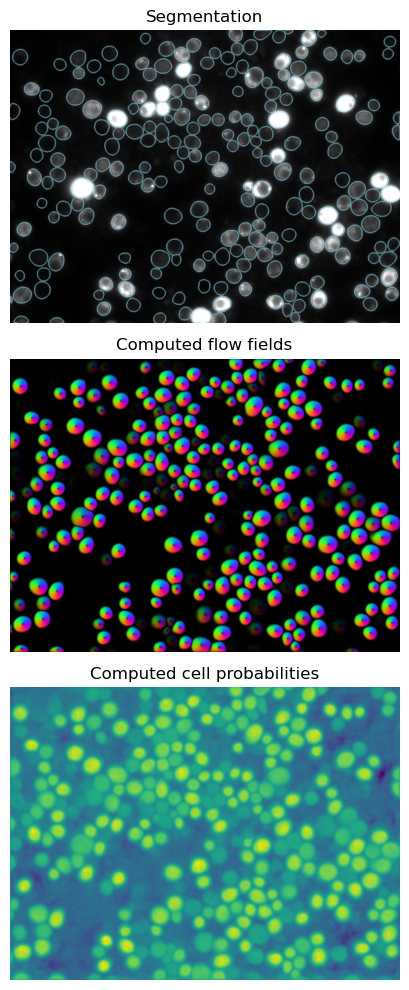

In [18]:
from scipy import ndimage
from skimage import segmentation

b = segmentation.find_boundaries(masks, mode='thick')
b = ndimage.binary_dilation(b, iterations=2)

fig, axs = plt.subplots(3, 1, figsize=(5, 10))

axs[0].imshow(img, cmap='gray')
axs[0].imshow(b, cmap='tab20', alpha=0.5 * b)
axs[0].set_title('Segmentation')

axs[1].imshow(flows[0])
axs[1].set_title('Computed flow fields')

axs[2].imshow(flows[2])
axs[2].set_title('Computed cell probabilities')

for ax in axs:
    ax.axis('off')
plt.tight_layout()